### UPDRS is Static: The Unified Parkinson’s Disease Rating Scale (UPDRS) is typically measured at specific points in time (like after a clinical assessment) and isn't inherently tied to continuous time-series data like sensor signals.

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import plotly.express as px
import seaborn as sns


from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [14]:
data_directory = 'G:/My Drive/kaggle_data/FoG_prediction/'

In [15]:
def explore_dataframe(df):
    print("Shape of dataframe:", df.shape)
    
    display(df.head())
    
    print("Info of dataframe:\n")
    df.info()
         
    print("Missing values in dataframe:\n", df.isnull().sum())
    
    print("Duplicate rows in dataframe:", df.duplicated().sum())

### Metadata

In [16]:
tdcsfog_metadata_df = pd.read_csv(data_directory+"tdcsfog_metadata.csv")
defog_metadata_df = pd.read_csv(data_directory+"defog_metadata.csv")
subjects_df = pd.read_csv(data_directory+"subjects.csv")
events_df = pd.read_csv(data_directory+"events.csv")
tasks_df = pd.read_csv(data_directory+"tasks.csv")
daily_metadata_df = pd.read_csv(data_directory+"daily_metadata.csv")

In [17]:
explore_dataframe(tdcsfog_metadata_df)

Shape of dataframe: (833, 5)


,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Id          833 non-null    object
 1   Subject     833 non-null    object
 2   Visit       833 non-null    int64 
 3   Test        833 non-null    int64 
 4   Medication  833 non-null    object
dtypes: int64(2), object(3)
memory usage: 32.7+ KB
Missing values in dataframe:
 Id            0
Subject       0
Visit         0
Test          0
Medication    0
dtype: int64
Duplicate rows in dataframe: 0


In [18]:
explore_dataframe(defog_metadata_df)

Shape of dataframe: (137, 4)


,Id,Subject,Visit,Medication
0,02ab235146,e1f62e,2,on
1,02ea782681,ae2d35,2,on
2,06414383cf,8c1f5e,2,off
3,092b4c1819,2874c5,1,off
4,0a900ed8a2,0e3d49,2,on


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Id          137 non-null    object
 1   Subject     137 non-null    object
 2   Visit       137 non-null    int64 
 3   Medication  137 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.4+ KB
Missing values in dataframe:
 Id            0
Subject       0
Visit         0
Medication    0
dtype: int64
Duplicate rows in dataframe: 0


In [19]:
explore_dataframe(subjects_df)

Shape of dataframe: (173, 8)


,Subject,Visit,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,00f674,2.0,63,M,27.0,43.0,49.0,24
1,00f674,1.0,63,M,27.0,31.0,30.0,26
2,02bc69,NaN,69,M,4.0,21.0,NaN,22
3,040587,2.0,75,M,26.0,52.0,69.0,21
4,040587,1.0,75,M,26.0,47.0,75.0,24


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subject       173 non-null    object 
 1   Visit         111 non-null    float64
 2   Age           173 non-null    int64  
 3   Sex           173 non-null    object 
 4   YearsSinceDx  173 non-null    float64
 5   UPDRSIII_On   172 non-null    float64
 6   UPDRSIII_Off  132 non-null    float64
 7   NFOGQ         173 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 10.9+ KB
Missing values in dataframe:
 Subject          0
Visit           62
Age              0
Sex              0
YearsSinceDx     0
UPDRSIII_On      1
UPDRSIII_Off    41
NFOGQ            0
dtype: int64
Duplicate rows in dataframe: 0


In [20]:
explore_dataframe(events_df)

Shape of dataframe: (3544, 5)


,Id,Init,Completion,Type,Kinetic
0,003f117e14,8.61312,14.7731,Turn,1.0
1,009ee11563,11.38470,41.1847,Turn,1.0
2,009ee11563,54.66470,58.7847,Turn,1.0
3,011322847a,28.09660,30.2966,Turn,1.0
4,01d0fe7266,30.31840,31.8784,Turn,1.0


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          3544 non-null   object 
 1   Init        3544 non-null   float64
 2   Completion  3544 non-null   float64
 3   Type        2502 non-null   object 
 4   Kinetic     2502 non-null   float64
dtypes: float64(3), object(2)
memory usage: 138.6+ KB
Missing values in dataframe:
 Id               0
Init             0
Completion       0
Type          1042
Kinetic       1042
dtype: int64
Duplicate rows in dataframe: 0


In [21]:
explore_dataframe(tasks_df)

Shape of dataframe: (2817, 4)


,Id,Begin,End,Task
0,02ab235146,10.00,190.48,Rest1
1,02ab235146,211.24,271.56,Rest2
2,02ab235146,505.88,522.40,4MW
3,02ab235146,577.96,594.64,4MW-C
4,02ab235146,701.32,715.28,MB1


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2817 entries, 0 to 2816
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      2817 non-null   object 
 1   Begin   2817 non-null   float64
 2   End     2817 non-null   float64
 3   Task    2817 non-null   object 
dtypes: float64(2), object(2)
memory usage: 88.2+ KB
Missing values in dataframe:
 Id       0
Begin    0
End      0
Task     0
dtype: int64
Duplicate rows in dataframe: 0


### EDA

In [22]:
print(f"Number of unique Ids in tdcsfog metadata: {len(tdcsfog_metadata_df.Id.unique())}")
print(f"Number of unique Ids in defog metadata: {len(defog_metadata_df.Id.unique())}")
print(f"Number of unique Subjects in subjects data: {len(subjects_df.Subject.unique())}")
print(f"Number of unique Ids in events data: {len(events_df.Id.unique())}")
print(f"Number of unique Ids in tasks data: {len(tasks_df.Id.unique())}")

Number of unique Ids in tdcsfog metadata: 833
Number of unique Ids in defog metadata: 137
Number of unique Subjects in subjects data: 136
Number of unique Ids in events data: 535
Number of unique Ids in tasks data: 137


In [23]:
# Remove NaN values
on_scores = subjects_df['UPDRSIII_On'].dropna()
off_scores = subjects_df['UPDRSIII_Off'].dropna()

# Perform KDE using scipy's gaussian_kde
kde_on = gaussian_kde(on_scores)
kde_off = gaussian_kde(off_scores)

# Create a range for UPDRS scores
x_range = np.linspace(0, max(on_scores.max(), off_scores.max()), 100)

# Calculate KDE for the range
kde_values_on = kde_on(x_range)
kde_values_off = kde_off(x_range)

fig = go.Figure()

# Add KDE for UPDRSIII_On
fig.add_trace(go.Scatter(
    x=x_range, y=kde_values_on, 
    mode='lines', 
    name='On', 
    line=dict(color='purple', width=3),
    fill='tozeroy', opacity=0.4
))

# Add KDE for UPDRSIII_Off
fig.add_trace(go.Scatter(
    x=x_range, y=kde_values_off, 
    mode='lines', 
    name='Off', 
    line=dict(color='orange', width=3),
    fill='tozeroy', opacity=0.4
))

fig.update_layout(
    xaxis_title='UPDRS Score',
    yaxis_title='Density',
    xaxis=dict(titlefont=dict(color='black')),
    yaxis=dict(titlefont=dict(color='black')),
    legend_title="Medication Status"
)

fig.show()

In [24]:
melted_df = subjects_df.melt(value_vars=['UPDRSIII_On', 'UPDRSIII_Off'],
                              var_name='Medication_Status',
                              value_name='UPDRS_Score')

# Create the horizontal boxplot
fig = px.box(melted_df, 
              y='Medication_Status',  
              x='UPDRS_Score', 
              title='UPDRS Scores by Medication Status',
              labels={'Medication_Status': '', 'UPDRS_Score': 'UPDRS Score'},
              color='Medication_Status', 
              color_discrete_sequence=["purple", "orange"]  
             )


fig.show()

In [25]:
# Melt the DataFrame to long format to include both UPDRS On and Off scores
melted_df = subjects_df.melt(id_vars=['Subject', 'Sex'], 
                             value_vars=['UPDRSIII_On', 'UPDRSIII_Off'],
                             var_name='Medication_Status', 
                             value_name='UPDRS_Score')

# Remove rows with missing UPDRS scores
melted_df_clean = melted_df.dropna(subset=['UPDRS_Score', 'Sex'])

# Create a boxplot comparing UPDRS On and Off scores by Sex
fig = px.box(melted_df_clean, 
             y='Medication_Status', 
             x='UPDRS_Score', 
             color='Sex',
             title='UPDRS On and Off Scores by Sex',
             labels={'UPDRS_Score': 'UPDRS Score', 'Medication_Status': ''},
             color_discrete_sequence=["blue", "red"]  
            )


fig.show()

### Unsurprisingly, those off medications have higher UPDRS scores. 
### The distribution of UPDRS scores for men is centered around higher scores than for women.

In [26]:
tdcsfog_metadata_df['Dataset'] = 'tdcsfog'
defog_metadata_df['Dataset'] = 'defog'

In [27]:
tdcsfog_metadata_filtered = tdcsfog_metadata_df[['Id', 'Subject','Visit', 'Medication','Dataset']]
defog_metadata_filtered = defog_metadata_df[['Id', 'Subject','Visit', 'Medication','Dataset']]

# Concatenate the two metadata dataframes
combined_metadata = pd.concat([tdcsfog_metadata_filtered, defog_metadata_filtered], axis=0).reset_index(drop=True)
combined_metadata

,Id,Subject,Visit,Medication,Dataset
0,003f117e14,4dc2f8,3,on,tdcsfog
1,009ee11563,f62eec,4,on,tdcsfog
2,011322847a,231c3b,2,on,tdcsfog
3,01d0fe7266,231c3b,2,off,tdcsfog
4,024418ba39,fa8764,19,on,tdcsfog
...,...,...,...,...,...
965,f3a921edee,1a778d,1,off,defog
966,f40e8c6ebe,575c60,1,off,defog
967,f8ddbdd98d,107712,1,on,defog
968,f9efef91fb,5d9cae,2,off,defog


In [28]:
merged_with_notna_visit = pd.merge(
    combined_metadata,
    subjects_df[subjects_df['Visit'].notna()],  # Filter to include only valid visits
    on=['Subject', 'Visit'],
    how='left'
)

# Merge where Subject is valid, but Visit is NaN in subjects_df
# In this case, we keep the Visit from train_df
subject_merged_df = pd.merge(
    merged_with_notna_visit,
    subjects_df[subjects_df['Visit'].isna()],  # Only include rows with NaN in Visit
    on='Subject',
    how='left',
    suffixes=('', '_subject_nan')  # Suffix for columns from subjects_df
)

# Clean up the DataFrame
# Now, we need to make sure we combine the relevant columns,
# particularly for 'Age', 'Sex', etc., taking non-null values from both sides.
subject_merged_df['Age'] = subject_merged_df['Age'].combine_first(subject_merged_df['Age_subject_nan'])
subject_merged_df['Sex'] = subject_merged_df['Sex'].combine_first(subject_merged_df['Sex_subject_nan'])
subject_merged_df['YearsSinceDx'] = subject_merged_df['YearsSinceDx'].combine_first(subject_merged_df['YearsSinceDx_subject_nan'])
subject_merged_df['UPDRSIII_On'] = subject_merged_df['UPDRSIII_On'].combine_first(subject_merged_df['UPDRSIII_On_subject_nan'])
subject_merged_df['UPDRSIII_Off'] = subject_merged_df['UPDRSIII_Off'].combine_first(subject_merged_df['UPDRSIII_Off_subject_nan'])
subject_merged_df['NFOGQ'] = subject_merged_df['NFOGQ'].combine_first(subject_merged_df['NFOGQ_subject_nan'])

# Drop any unnecessary columns
subject_merged_df.drop(columns=['Test','Age_subject_nan', 'Sex_subject_nan', 'YearsSinceDx_subject_nan', 
                              'UPDRSIII_On_subject_nan', 'UPDRSIII_Off_subject_nan', 
                              'NFOGQ_subject_nan','Visit_subject_nan'], inplace=True, errors='ignore')


subject_merged_df['UPDRS_Score'] = np.where(
    subject_merged_df['Medication'] == 'on',  # Condition for "on"
    subject_merged_df['UPDRSIII_On'],         # Value if condition is True
    subject_merged_df['UPDRSIII_Off']         # Value if condition is False
)

subject_merged_df = subject_merged_df.drop(columns=['UPDRSIII_On', 'UPDRSIII_Off'])
subject_merged_df

,Id,Subject,Visit,Medication,Dataset,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score
0,003f117e14,4dc2f8,3,on,tdcsfog,68.0,F,9.0,15.0,17.0
1,009ee11563,f62eec,4,on,tdcsfog,71.0,M,10.0,24.0,42.0
2,011322847a,231c3b,2,on,tdcsfog,67.0,M,12.0,19.0,27.0
3,01d0fe7266,231c3b,2,off,tdcsfog,67.0,M,12.0,19.0,28.0
4,024418ba39,fa8764,19,on,tdcsfog,60.0,F,7.0,19.0,30.0
...,...,...,...,...,...,...,...,...,...,...
965,f3a921edee,1a778d,1,off,defog,65.0,M,7.0,25.0,54.0
966,f40e8c6ebe,575c60,1,off,defog,28.0,M,4.0,25.0,50.0
967,f8ddbdd98d,107712,1,on,defog,82.0,F,11.0,21.0,38.0
968,f9efef91fb,5d9cae,2,off,defog,72.0,M,14.0,17.0,45.0


In [29]:
subject_merged_df.isna().sum()

Id              0
Subject         0
Visit           0
Medication      0
Dataset         0
Age             0
Sex             0
YearsSinceDx    0
NFOGQ           0
UPDRS_Score     3
dtype: int64

In [30]:
subject_merged_df[subject_merged_df.UPDRS_Score.isna()].Subject.unique().tolist()

['e8919c']

In [31]:
subject_merged_df['UPDRS_Score'].fillna(subject_merged_df['UPDRS_Score'].median(), inplace=True)
subject_merged_df.isna().sum()

Id              0
Subject         0
Visit           0
Medication      0
Dataset         0
Age             0
Sex             0
YearsSinceDx    0
NFOGQ           0
UPDRS_Score     0
dtype: int64

In [32]:
subject_merged_df.dtypes

Id               object
Subject          object
Visit             int64
Medication       object
Dataset          object
Age             float64
Sex              object
YearsSinceDx    float64
NFOGQ           float64
UPDRS_Score     float64
dtype: object

In [33]:
subject_merged_df['Sex'] = subject_merged_df['Sex'].replace({'F': 0, 'M': 1})
subject_merged_df['Medication'] = subject_merged_df['Medication'].replace({'off': 0, 'on': 1})

In [34]:
event_merged_df = subject_merged_df.merge(events_df, on='Id', how='left')
event_merged_df

,Id,Subject,Visit,Medication,Dataset,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Init,Completion,Type,Kinetic
0,003f117e14,4dc2f8,3,1,tdcsfog,68.0,0,9.0,15.0,17.0,8.61312,14.7731,Turn,1.0
1,009ee11563,f62eec,4,1,tdcsfog,71.0,1,10.0,24.0,42.0,11.38470,41.1847,Turn,1.0
2,009ee11563,f62eec,4,1,tdcsfog,71.0,1,10.0,24.0,42.0,54.66470,58.7847,Turn,1.0
3,011322847a,231c3b,2,1,tdcsfog,67.0,1,12.0,19.0,27.0,28.09660,30.2966,Turn,1.0
4,01d0fe7266,231c3b,2,0,tdcsfog,67.0,1,12.0,19.0,28.0,30.31840,31.8784,Turn,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3974,f9fc61ce85,040587,1,1,defog,75.0,1,26.0,24.0,47.0,620.74000,623.8450,Walking,0.0
3975,f9fc61ce85,040587,1,1,defog,75.0,1,26.0,24.0,47.0,774.67800,774.8330,Walking,1.0
3976,f9fc61ce85,040587,1,1,defog,75.0,1,26.0,24.0,47.0,924.11900,925.6270,Turn,1.0
3977,f9fc61ce85,040587,1,1,defog,75.0,1,26.0,24.0,47.0,983.03900,984.0380,Turn,0.0


In [35]:
event_merged_df.isna().sum()

Id                 0
Subject            0
Visit              0
Medication         0
Dataset            0
Age                0
Sex                0
YearsSinceDx       0
NFOGQ              0
UPDRS_Score        0
Init             435
Completion       435
Type            1477
Kinetic         1477
dtype: int64

In [36]:
event_merged_df['Type'].fillna('None', inplace=True)
event_merged_df['Init'].fillna(0, inplace=True)
event_merged_df['Completion'].fillna(0, inplace=True)
event_merged_df['Kinetic'].fillna(-1, inplace=True)


In [37]:
event_merged_df.Type.value_counts()/len(event_merged_df)*100

Type
Turn               50.188490
None               37.119879
Walking            10.002513
StartHesitation     2.689118
Name: count, dtype: float64

In [38]:
event_merged_df['Event_Duration'] = event_merged_df['Completion'] - event_merged_df['Init']

In [39]:
event_merged_df.drop(['Dataset','Visit','Subject','Id', 'Init', 'Completion'], axis=1, inplace=True)

In [40]:
event_merged_df

,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Type,Kinetic,Event_Duration
0,1,68.0,0,9.0,15.0,17.0,Turn,1.0,6.15998
1,1,71.0,1,10.0,24.0,42.0,Turn,1.0,29.80000
2,1,71.0,1,10.0,24.0,42.0,Turn,1.0,4.12000
3,1,67.0,1,12.0,19.0,27.0,Turn,1.0,2.20000
4,0,67.0,1,12.0,19.0,28.0,Turn,1.0,1.56000
...,...,...,...,...,...,...,...,...,...
3974,1,75.0,1,26.0,24.0,47.0,Walking,0.0,3.10500
3975,1,75.0,1,26.0,24.0,47.0,Walking,1.0,0.15500
3976,1,75.0,1,26.0,24.0,47.0,Turn,1.0,1.50800
3977,1,75.0,1,26.0,24.0,47.0,Turn,0.0,0.99900


In [41]:
event_merged_df.dtypes

Medication          int64
Age               float64
Sex                 int64
YearsSinceDx      float64
NFOGQ             float64
UPDRS_Score       float64
Type               object
Kinetic           float64
Event_Duration    float64
dtype: object

In [42]:
event_merged_df.Type.value_counts()

Type
Turn               1997
None               1477
Walking             398
StartHesitation     107
Name: count, dtype: int64

In [43]:
event_merged_df = pd.get_dummies(event_merged_df, columns=['Type'], prefix='Type', dtype=int)


In [44]:
event_merged_df = pd.get_dummies(event_merged_df, columns=['Kinetic'], prefix='Kinetic', dtype=int)

event_merged_df = event_merged_df.rename(columns={
    'Kinetic_-1.0': 'None_Kinetic',
    'Kinetic_0.0': 'Not_Kinetic',
    'Kinetic_1.0': 'Is_Kinetic'
})


In [45]:
event_merged_df = event_merged_df.drop_duplicates().reset_index(drop=True)
event_merged_df 

,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Event_Duration,Type_None,Type_StartHesitation,Type_Turn,Type_Walking,None_Kinetic,Not_Kinetic,Is_Kinetic
0,1,68.0,0,9.0,15.0,17.0,6.15998,0,0,1,0,0,0,1
1,1,71.0,1,10.0,24.0,42.0,29.80000,0,0,1,0,0,0,1
2,1,71.0,1,10.0,24.0,42.0,4.12000,0,0,1,0,0,0,1
3,1,67.0,1,12.0,19.0,27.0,2.20000,0,0,1,0,0,0,1
4,0,67.0,1,12.0,19.0,28.0,1.56000,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3585,1,75.0,1,26.0,24.0,47.0,3.10500,0,0,0,1,0,1,0
3586,1,75.0,1,26.0,24.0,47.0,0.15500,0,0,0,1,0,0,1
3587,1,75.0,1,26.0,24.0,47.0,1.50800,0,0,1,0,0,0,1
3588,1,75.0,1,26.0,24.0,47.0,0.99900,0,0,1,0,0,1,0


In [46]:
# Function to train the model and evaluate performance
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'R-squared': r2
    }


In [47]:
# Shuffle the DataFrame
shuffled_df = event_merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

X = shuffled_df.drop(columns=['UPDRS_Score'])
y = shuffled_df['UPDRS_Score']

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

# Define models to evaluate
models = [
    (LinearRegression(), "Linear Regression"),
    (KNeighborsRegressor(n_neighbors=10), "KNN"),
    (SVR(kernel='linear'), "Support Vector Regression"),
    (RandomForestRegressor(), "Random Forest"),
    (GradientBoostingRegressor(), "Gradient Boosting"),
    (xgb.XGBRegressor(), "XGBoost"),
    (lgb.LGBMRegressor(), "LightGBM"),
    (CatBoostRegressor(silent=True), "CatBoost")
]

# Iterate over models and evaluate them
for model, name in models:
    result = train_and_evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results.append(result)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

c:\Users\35262\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\35262\AppData\Local\Programs\Python\Python39\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 354
[LightGBM] [Info] Number of data points in the train set: 2872, number of used features: 13
[LightGBM] [Info] Start training from score 44.018106


In [48]:
results_df.sort_values(['RMSE'])

,Model,RMSE,R-squared
3,Random Forest,1.593654,0.977776
5,XGBoost,1.777530,0.972352
7,CatBoost,1.991701,0.965288
6,LightGBM,2.447645,0.947576
1,KNN,5.241503,0.759594
4,Gradient Boosting,5.687473,0.716944
2,Support Vector Regression,9.533297,0.204719
0,Linear Regression,9.557030,0.200755


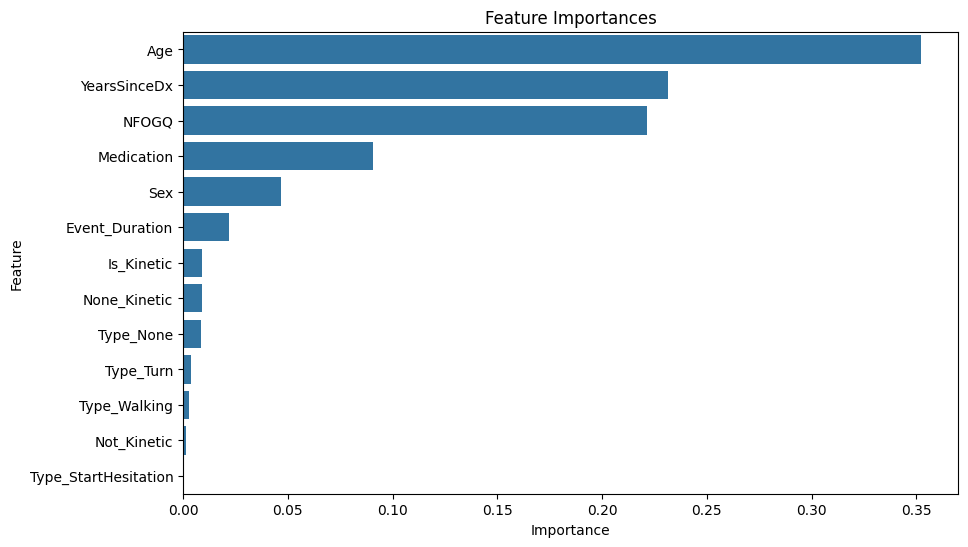

In [49]:
# Train a Random Forest model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.show()

In [50]:
event_merged_df[event_merged_df.UPDRS_Score==event_merged_df.UPDRS_Score.max()]

,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Event_Duration,Type_None,Type_StartHesitation,Type_Turn,Type_Walking,None_Kinetic,Not_Kinetic,Is_Kinetic
290,1,76.0,1,17.0,24.0,79.0,5.32,0,0,1,0,0,0,1
291,1,76.0,1,17.0,24.0,79.0,6.68,0,1,0,0,0,0,1
292,1,76.0,1,17.0,24.0,79.0,1.44,0,0,1,0,0,0,1
293,1,76.0,1,17.0,24.0,79.0,0.92,0,0,1,0,0,0,1
309,1,76.0,1,17.0,24.0,79.0,4.72,0,0,1,0,0,0,1
310,1,76.0,1,17.0,24.0,79.0,1.60,0,0,1,0,0,0,1
311,1,76.0,1,17.0,24.0,79.0,9.44,0,0,0,1,0,1,0
312,1,76.0,1,17.0,24.0,79.0,3.24,0,0,1,0,0,0,1
1022,1,76.0,1,17.0,24.0,79.0,4.54,0,1,0,0,0,1,0
1023,1,76.0,1,17.0,24.0,79.0,34.10,0,0,0,1,0,1,0


In [51]:
top_n = 5
top_features = feature_importance_df.head(top_n)['Feature'].values

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Retrain the Random Forest model using the top features
rf_model_top = RandomForestRegressor()
rf_model_top.fit(X_train_top, y_train)

# Make predictions with the top features
y_pred_rf_top = rf_model_top.predict(X_test_top)

# Evaluate the model's performance
rmse_rf_top = root_mean_squared_error(y_test, y_pred_rf_top)
r2_rf_top = r2_score(y_test, y_pred_rf_top)

print("Random Forest RMSE with Top Features:", rmse_rf_top)
print("Random Forest R-squared with Top Features:", r2_rf_top)

Random Forest RMSE with Top Features: 1.6723733660857496
Random Forest R-squared with Top Features: 0.975526237126567
